In [2]:
import pandas as pd

df = pd.read_csv("paddydataset.csv")

CO_43         posterior mean = 22540 kg, 95% CI = (21876, 23205)
ponmani       posterior mean = 22411 kg, 95% CI = (21867, 22956)
delux ponni   posterior mean = 22614 kg, 95% CI = (22035, 23194)


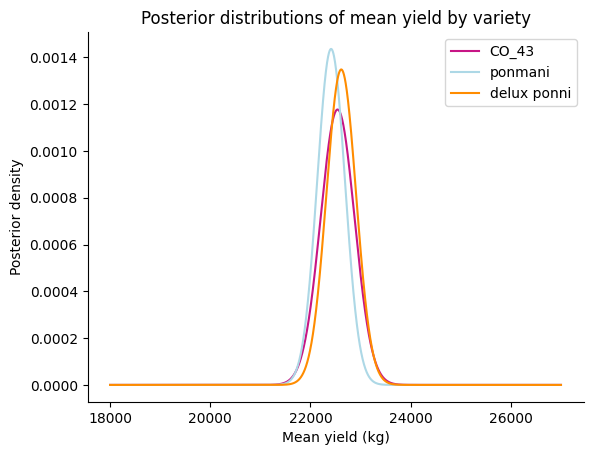

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#yields for each variety
varieties = ['CO_43', 'ponmani', 'delux ponni']
yields = {v: df.loc[df['Variety'] == v, 'Paddy yield(in Kg)'].values for v in varieties}

#priors
prior_mean, prior_sd = 22500, 5000

#grid over plausible mean yields
grid = np.linspace(18000, 27000, 5000)
dx = grid[1] - grid[0]

#compute posterior for each variety's mean
posteriors = {}
summaries = {}

for v in varieties:
    y = yields[v]
    n, m, s = len(y), y.mean(), y.std(ddof=1)
    se = s / np.sqrt(n)

    prior = np.exp(-0.5 * ((grid - prior_mean) / prior_sd) ** 2)
    likelihood = np.exp(-0.5 * ((m - grid) / se) ** 2)
    post = prior * likelihood
    post /= np.trapezoid(post, grid)
    posteriors[v] = post

    post_mean = np.trapezoid(grid * post, grid)
    cdf = np.cumsum(post) * dx
    ci_low  = grid[np.searchsorted(cdf, 0.025)]
    ci_high = grid[np.searchsorted(cdf, 0.975)]
    summaries[v] = (post_mean, ci_low, ci_high)

    print(f"{v:12s}  posterior mean = {post_mean:.0f} kg, "
          f"95% CI = ({ci_low:.0f}, {ci_high:.0f})")

colors = {'CO_43': 'mediumvioletred', 'ponmani': 'lightblue', 'delux ponni': 'darkorange'}

for v in varieties:
    plt.plot(grid, posteriors[v], label=v, color=colors[v])
sns.despine()
plt.xlabel('Mean yield (kg)')
plt.ylabel('Posterior density')
plt.title('Posterior distributions of mean yield by variety')
plt.legend()
plt.show()